# Which exams have complete paired-image references?

You have received an export from two sites and need to decide which exams can enter
an analysis that requires **both image references on every export slot**. Before
excluding records, you want to distinguish expected absence from incomplete exports,
identify the records to ask the data provider about, and repeat the check on a corrected delivery.

This is a small, synthetic dataset. In **this export's specification**, MR records use
paired image references; CT records contain dose measurements instead. This is a rule
of the example export, not a general claim about MR or CT. Fieldwork will help us
check the observed data against that supplied specification.

By the end, we will have an eligible population, a completeness definition, a specific
exception to investigate, and a reusable check with a before/after result.

**Running this notebook:** use a Python 3.11–3.14 kernel with `fieldwork` and `IPython`
installed (`pip install fieldwork ipython` in that environment), then run the cells in
order. In a repository checkout, `uv sync --locked` prepares the development environment.
The saved outputs let you read the investigation without running it. No external data
or service is needed; the recipe round trip uses a temporary directory.

## 1. Understand what a row means

Each row is one export slot, identified here by `(exam_id, slot)`. Exams contribute
between one and three slots, so counting rows and counting exams answer different questions.

| Field | Meaning in this example |
| --- | --- |
| `site`, `exam_id`, `modality` | Site, globally unique exam identifier, and export workflow |
| `slot` | Slot number within an exam |
| `image_1`, `image_2` | File references for the two members of a pair, not image measurements |
| `dose` | A synthetic CT-only measurement; its value is not used in this investigation |

`None` is native missing data. The provider also uses **`-999` for an unavailable
second-image reference**, so we must pass that convention to every analysis. The
repeated dataframe index labels mimic concatenated exports; they are not row identifiers.

In [1]:
import pandas as pd
from IPython.display import SVG, display

import fieldwork as fw

missing = {"image_2": [-999]}
features = ["image_1", "image_2", "dose"]
df = pd.DataFrame(
    {
        "site": ["North"] * 7 + ["South"] * 5,
        "exam_id": ["N01"] * 3 + ["N02"] * 2 + ["N03"] * 2 + ["S01"] * 2 + ["S02"] + ["S03"] * 2,
        "modality": ["MR"] * 5 + ["CT"] * 2 + ["MR"] * 3 + ["CT"] * 2,
        "slot": [1, 2, 3, 1, 2, 1, 2, 1, 2, 1, 1, 2],
        "image_1": [10, 11, 12, 13, 14, None, None, 20, 21, 22, None, None],
        "image_2": [110, 111, 112, 113, 114, None, None, 120, -999, 122, None, None],
        "dose": [None] * 5 + [2, 3] + [None] * 3 + [4, 5],
    },
    index=[0] * 12,
)
display(df)

,site,exam_id,modality,slot,image_1,image_2,dose
0,North,N01,MR,1,10.0,110.0,NaN
0,North,N01,MR,2,11.0,111.0,NaN
0,North,N01,MR,3,12.0,112.0,NaN
0,North,N02,MR,1,13.0,113.0,NaN
0,North,N02,MR,2,14.0,114.0,NaN
0,North,N03,CT,1,NaN,NaN,2.0
0,North,N03,CT,2,NaN,NaN,3.0
0,South,S01,MR,1,20.0,120.0,NaN
0,South,S01,MR,2,21.0,-999.0,NaN
0,South,S02,MR,1,22.0,122.0,NaN


## 2. What patterns deserve a closer look?

Use `explore` when you first receive a table and need leads: it summarizes shared
availability, observed groupings, and possible census paths. We supply the sentinel
convention immediately so that `-999` is not mistaken for an image reference.

In [2]:
overview = fw.explore(df, missing=missing)
print(fw.render_plaintext(overview, max_lines=100))

Fieldwork \xb7 overview
Population: 12 rows
Search limits reached; review section coverage.
Analysis: 12 rows; presence=per_row
Availability families
  site, exam_id, modality, slot
Major availability signatures
  Present: site, exam_id, modality, slot, image_1, image_2 (7 rows)
  Present: site, exam_id, modality, slot, dose (4 rows)
  Present: site, exam_id, modality, slot, image_1 (1 rows)
Candidate grains
  exam_id: repeated grouping
    6 groups, 5 repeated
    11 determinant repeated rows
    2 exact targets, 2 with repeated support
    global targets tested 6/6
  modality: repeated grouping
    2 groups, 2 repeated
    12 determinant repeated rows
    0 exact targets, 0 with repeated support
    global targets tested 6/6
  site: repeated grouping
    2 groups, 2 repeated
    12 determinant repeated rows
    0 exact targets, 0 with repeated support
    global targets tested 6/6
  slot: repeated grouping
    3 groups, 2 repeated
    11 determinant repeated rows
    0 exact targets,

**Read the signatures first:** seven rows have both image references, four have dose
without either image reference, and one has only the first image reference. This
suggests two expected workflows and one record to investigate.

The family containing `site`, `exam_id`, `modality`, and `slot` means that those fields
share availability (all are populated); it does not mean they describe the same thing.
Likewise, an observed unique identifier is not proof of a permanent identifier contract.
The exact-target counts distinguish mappings with repeated support from those that
hold only on singleton groups. All six possible global targets were tested for each
candidate here; repeated support still does not certify entity meaning.
The suggested census paths are exploratory leads; we will choose dimensions for our
specific reporting question later.

Related names are another lead. `relationships` keeps naming evidence separate from
availability evidence. The indexed-name connection below suggests looking at the image
pair, but the export specification is what tells us that a pair is required.

In [3]:
connections = overview.relationships("image_1", kinds=["indexed_name"])
display(
    pd.DataFrame(
        {
            "connection": connections["kind"],
            "fields": connections["features"].map(lambda fields: [f["column"] for f in fields]),
        }
    )
)

,connection,fields
0,indexed_name,"[image_1, image_2]"


## 3. Is missingness expected for this workflow?

Use `missingness` for a focused count of the three payload fields, and `by=["modality"]`
to see whether absence is concentrated in a known workflow. We retain just one example
row per finding so we can later demonstrate the difference between an example and a population.

`min_implication=0.85` includes directional presence patterns with at least 85% observed
agreement among rows where the first field is present. This is a discovery threshold,
not our acceptance criterion: the analysis still requires complete pairs on every slot.

In [4]:
availability = fw.missingness(
    df,
    features=features,
    by=["modality"],
    missing=missing,
    min_implication=0.85,
    example_limit=1,
)
display(availability.to_frame("availability").round(3))
context_counts = pd.DataFrame(
    [
        {"modality": context["values"]["modality"]["value"], **count}
        for context in availability["contexts"]
        for count in context["availability"]
    ]
)
display(context_counts)

,feature,populated,missing,denominator,populated_fraction
0,image_1,8,4,12,0.667
1,image_2,7,5,12,0.583
2,dose,4,8,12,0.333


,modality,feature,populated,denominator
0,MR,image_1,8,8
1,MR,image_2,7,8
2,MR,dose,0,8
3,CT,image_1,0,4
4,CT,image_2,0,4
5,CT,dose,4,4


Across the whole delivery, `image_2` is populated on **7/12 rows (58.3%)**. That number
mixes four CT rows, which are not expected to have image pairs, with eight MR rows.
Within MR, the figure is **7/8 (87.5%)**. Dose is present on all four CT rows and absent
on all eight MR rows, consistent with the supplied specification.

**Decision:** investigate completeness within MR. Select this population from the
modality context, independently of whether its image fields are populated. Selecting
only rows that already have images would hide completely missing pairs.

`inspect` retrieves the bounded saved examples. `select` reconstructs **all** matching
source positions as a reusable `Scope`, including rows with duplicate index labels.

In [5]:
mr_context = next(
    context
    for context in availability["contexts"]
    if context["values"]["modality"]["value"] == "MR"
)
mr_examples = availability.inspect(df, mr_context["finding_id"])
mr_scope = availability.select(df, mr_context["finding_id"], name="MR export slots")
display(mr_examples)
display(
    pd.DataFrame(
        [
            {"selection": "Saved example", "rows": len(mr_examples)},
            {"selection": "Complete MR population", "rows": len(mr_scope.positions)},
        ]
    )
)

,site,exam_id,modality,slot,image_1,image_2,dose
0,North,N01,MR,1,10.0,110.0,NaN


,selection,rows
0,Saved example,1
1,Complete MR population,8


The single saved example is not the eight-row cohort. Pass the selected scope to the
next analysis to keep that population explicit while retaining the original dataframe.
We can compare overall and MR-only availability to quantify the effect of this restriction.

In [6]:
row_evidence = fw.missingness(
    df,
    features=["image_1", "image_2"],
    scope=mr_scope,
    entity="exam_id",
    missing=missing,
)
population_comparison = fw.compare(availability, row_evidence)
population_change = population_comparison.to_frame("changes")
display(
    population_change.loc[
        population_change["feature"] == "image_2",
        [
            "feature",
            "before.populated",
            "before.denominator",
            "after.populated",
            "after.denominator",
            "populated_fraction_delta",
        ],
    ].round(3)
)

,feature,before.populated,before.denominator,after.populated,after.denominator,populated_fraction_delta
2,image_2,7,12,7.0,8.0,0.292


The `image_2` fraction increases by **0.292 (29.2 percentage points)** because the
population changes from all 12 rows to the eight MR rows. No records have been repaired:
this is a comparison of populations in one delivery, not improvement over time.

## 4. What does a complete exam mean?

`entity="exam_id"` identifies exams but **does not change the default counting unit**:
`row_evidence` still counts rows. Set `unit="entities"` to give each exam one observation,
regardless of its number of slots. Then choose what presence means within an exam:

- **Rows:** What fraction of MR slots have a second-image reference?
- **Entities, `any`:** What fraction of MR exams have at least one second-image reference?
- **Entities, `all`:** What fraction of MR exams have a second-image reference on every slot?

In [7]:
entity_any = fw.missingness(
    df,
    features=["image_1", "image_2"],
    scope=mr_scope,
    missing=missing,
    entity="exam_id",
    unit="entities",
    entity_presence="any",
)
entity_all = fw.missingness(
    df,
    features=["image_1", "image_2"],
    scope=mr_scope,
    missing=missing,
    entity="exam_id",
    unit="entities",
    entity_presence="all",
)
unit_rows = []
for question, result in [
    ("Slots with a second image", row_evidence),
    ("Exams with any second image", entity_any),
    ("Exams with a second image on every slot", entity_all),
]:
    count = next(a for a in result["availability"] if a["feature"] == "image_2")
    unit_rows.append({"question": question, **count})
unit_summary = pd.DataFrame(unit_rows).drop(columns=["feature"])
display(unit_summary)

,question,populated,missing,denominator,populated_fraction
0,Slots with a second image,7,1,8,0.875
1,Exams with any second image,4,0,4,1.000
2,Exams with a second image on every slot,3,1,4,0.750


The answers are **7/8 slots (87.5%)**, **4/4 exams (100%)** with at least one second
image, and **3/4 exams (75%)** with a second image on every slot. Unequal exam sizes
mean the row fraction gives more weight to exams with more slots.

**Decision:** use `entities` with `all` for the final completeness check. `image_1` is
present on every MR slot here, so the second-image result determines which exams have
complete pairs. For other datasets, check both fields: per-field `any` results alone
do not establish that a pair occurs on the same row.

## 5. Which record should we ask the provider about?

A directional presence finding lets us inspect rows that violate an observed pairing
pattern. First read its counts and compare its conditional fraction with the overall
baseline; a high fraction alone does not establish a useful relationship.

In [8]:
edge = next(
    finding
    for finding in availability["findings"]
    if finding["pattern"] == "presence_implication"
    and [f["column"] for f in finding["features"]] == ["image_1", "image_2"]
)
display(
    pd.DataFrame(
        [
            {
                key: edge["measurements"][key]
                for key in [
                    "both_present",
                    "antecedent_populated",
                    "conditional_presence",
                    "baseline_presence",
                ]
            }
        ]
    ).round(3)
)
exceptions = availability.inspect(df, edge["id"], exceptions=True)
exception_scope = availability.select(df, edge["id"], exceptions=True, name="Unpaired slots")
display(exceptions)
display(
    pd.DataFrame(
        [
            {
                "saved_examples": len(exceptions),
                "all_exception_rows": len(exception_scope.positions),
                "source_positions": list(exception_scope.positions),
            }
        ]
    )
)

,both_present,antecedent_populated,conditional_presence,baseline_presence
0,7,8,0.875,0.583


,site,exam_id,modality,slot,image_1,image_2,dose
0,South,S01,MR,2,21.0,-999.0,NaN


,saved_examples,all_exception_rows,source_positions
0,1,1,[8]


When `image_1` is present, `image_2` is present on **7/8 rows (87.5%)**, versus **7/12
(58.3%)** across the delivery. Here the pairing reflects the workflow split; it is not
evidence of causation. The exception is **South / S01 / slot 2**, at zero-based source
position **8**. Its raw `-999` remains visible during inspection even though we count it
as missing. Index label `0` alone would not identify this row.

There is one exception in this dataset, so the saved example happens to be exhaustive.
On larger data, use `select` (or `inspect(..., all_matches=True)`) for the full population.
To understand the affected exam, select the entity finding for **some, but not all,
slots populated**. That retrieves both slots of S01, including the complete slot.

In [9]:
partial_exam = next(
    finding
    for finding in row_evidence["findings"]
    if finding["pattern"] == "entity_availability"
    and finding["selector"]["feature"] == "image_2"
    and finding["selector"]["presence_pattern"] == "some"
)
affected_scope = row_evidence.select(df, partial_exam["id"], name="Partially populated MR exams")
affected_rows = df.iloc[list(affected_scope.positions)]
display(affected_rows)

,site,exam_id,modality,slot,image_1,image_2,dose
0,South,S01,MR,1,20.0,120.0,NaN
0,South,S01,MR,2,21.0,-999.0,NaN


**Next action:** ask the provider whether S01 slot 2's second reference was omitted
from the export or whether the underlying file is unavailable. Presence analysis identifies
the gap; it cannot determine its cause or validate the contents of a referenced file.

## 6. Where does the affected exam sit in the delivery?

Use a census to organize the eligible population for a site-level review. We want sites
first, then exams, so supply `start_with=["site"]` and limit the candidate fields to
`site` and `exam_id`. Review the recommendation's explanation before using it: the
highest-ranked path reflects these choices and observed data, not a universal best hierarchy.

In [10]:
paths = fw.suggest_paths(
    df,
    features=["site", "exam_id"],
    start_with=["site"],
    max_dimensions=2,
    scope=mr_scope,
    missing=missing,
)
if paths.best is None:
    raise RuntimeError("No census path was found for the example's MR population")
print("Chosen path:", " > ".join(paths.best.dimensions))
print(paths["paths"][0]["explanation"])

Chosen path: site > exam_id
Observed prefix groups: site: 2 → exam_id: 4; Supported coarse-to-fine nesting: site → exam_id; Availability nonmodal fractions: 0, 0


The explanation reports **two site groups followed by four exam groups**, with supported
site-to-exam nesting. That matches our reporting question, so we accept this path.
`paths.best.census(df)` preserves the selected population and missing-value conventions;
passing just a tuple of dimensions would not carry that context.

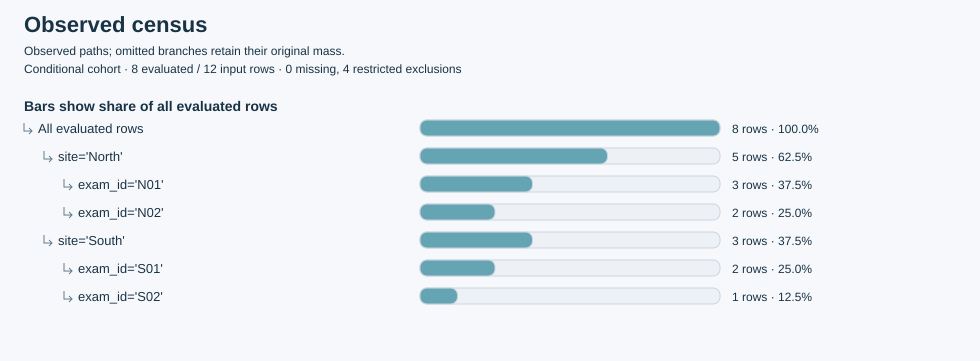

,input_rows,evaluated_rows,restriction_excluded_rows,missing_excluded_rows
0,12,8,4,0


In [11]:
tree = paths.best.census(df)
display(SVG(fw.render_svg(tree)))
population = tree["scopes"][0]
display(
    pd.DataFrame(
        [
            {
                key: population[key]
                for key in [
                    "input_rows",
                    "evaluated_rows",
                    "restriction_excluded_rows",
                    "missing_excluded_rows",
                ]
            }
        ]
    )
)

Read the tree counts as **rows (slots), not exams**: North has five MR slots across
N01 and N02; South has three across S01 and S02. Each site contributes two MR exams.
The accounting starts with 12 rows and evaluates eight after restricting out four CT
rows. There are no missing-value exclusions on the chosen dimensions (`site`, `exam_id`),
so the incomplete image slot is still represented.

Combined with the exception evidence, the review note is: **one of South's two MR exams
(S01) is incomplete; all other MR exams have complete references on every exported slot**.
The census organizes the cohort; the completeness finding supplies that assessment.

## 7. Did the corrected delivery resolve the gap?

Suppose the provider returns the same slots with S01's missing reference recovered.
The following copy simulates that corrected delivery; assigning the synthetic reference
is only constructing test data, not a way to repair a real missing image.

A `Recipe` saves the **analysis settings**, including the counting unit and sentinel
convention. A result or scope is evidence tied to one ordered source dataset. Rebuild
the MR scope from the new delivery, then pass it as a run override; do not reuse the
old scope or store it in the recipe.

In [12]:
next_delivery = df.copy()
next_delivery.loc[(next_delivery["exam_id"] == "S01") & (next_delivery["slot"] == 2), "image_2"] = (
    121
)
next_cohorts = fw.missingness(
    next_delivery,
    features=features,
    by=["modality"],
    missing=missing,
    example_limit=1,
)
next_mr_context = next(
    context
    for context in next_cohorts["contexts"]
    if context["values"]["modality"]["value"] == "MR"
)
next_mr_scope = next_cohorts.select(
    next_delivery, next_mr_context["finding_id"], name="MR export slots"
)

Save and reload the recipe to demonstrate the actual round trip. The temporary directory
is removed when this cell finishes; in a real project, use a durable path such as
`Path("availability-recipe.json")`. The recipe does not encode the MR selection rule,
so retain that cohort-selection step alongside it when adapting the workflow.

In [13]:
from pathlib import Path
from tempfile import TemporaryDirectory

recipe = fw.Recipe(
    "missingness",
    {
        "features": ["image_1", "image_2"],
        "entity": "exam_id",
        "unit": "entities",
        "entity_presence": "all",
        "missing": missing,
    },
    notes="Complete references on every MR export slot; select MR anew for each delivery.",
)
with TemporaryDirectory() as directory:
    recipe_path = Path(directory) / "availability-recipe.json"
    recipe.save(recipe_path)
    loaded_recipe = fw.Recipe.load(recipe_path)
    before_delivery = loaded_recipe.run(df, scope=mr_scope)
    after_delivery = loaded_recipe.run(next_delivery, scope=next_mr_scope)

delivery_comparison = fw.compare(before_delivery, after_delivery)
delivery_changes = delivery_comparison.to_frame("changes")
display(
    delivery_changes[
        [
            "feature",
            "before.populated",
            "before.denominator",
            "after.populated",
            "after.denominator",
            "populated_fraction_delta",
        ]
    ]
)

,feature,before.populated,before.denominator,after.populated,after.denominator,populated_fraction_delta
0,image_1,4,4,4,4,0.00
1,image_2,3,4,4,4,0.25


`image_1` remains complete for **4/4 exams**. `image_2` rises from **3/4 to 4/4**, a
fraction delta of **+0.25 (25 percentage points)**. Unlike the earlier population
comparison, this comparison uses two deliveries with the same MR eligibility rule,
exam denominator, `all` aggregation, and missing-value convention. The simulated
re-export resolves the single reference gap.

For unrelated future deliveries, also check cohort composition and denominators before
interpreting a rate change. `compare` reports availability differences; it does not prove
that a specific record was repaired or that two cohorts are equivalent.

## 8. Keep the evidence and write the conclusion

Use `to_dict()` to save evidence about the original delivery. This complements the recipe:
the saved result can still render without the source, while inspecting or selecting rows
requires the original ordered dataframe. Here we round-trip through JSON and recover the
original exception even after analyzing the corrected delivery.

In [14]:
import json

saved_evidence = json.dumps(availability.to_dict(), allow_nan=False)
restored = fw.InvestigationResult.from_dict(json.loads(saved_evidence))
display(restored.inspect(df, edge["id"], exceptions=True))

,site,exam_id,modality,slot,image_1,image_2,dose
0,South,S01,MR,2,21.0,-999.0,NaN


**Investigation conclusion**

- **Population:** eight MR export slots from four exams; the four CT slots belong to a
  different workflow and are outside the paired-image eligibility rule.
- **Initial result:** seven of eight MR slots contain both references, but only three
  of four exams meet the every-slot requirement. An `any`-presence check would have
  counted all four exams and concealed the incomplete slot.
- **Evidence and action:** South / S01 / slot 2 has a missing second-image reference.
  Inspect the full affected exam and ask the provider to resolve or explain that gap
  before including S01 in an analysis that requires complete pairs.
- **Corrected delivery:** reapplying the saved settings with a newly selected MR scope
  yields four complete exams out of four. This establishes reference availability;
  file existence, readability, and suitability for analysis need their own checks.

**Adapting this investigation:** establish your row meaning and expected fields first;
choose eligibility independently of the outcome; decide whether rows, any-row presence,
or all-row presence answers your question; then inspect evidence before choosing an action.
See [the investigation guide](../docs/investigation.md) for additional scope and recipe
semantics, and [the Python companion](investigation.py) for the compact executable workflow.